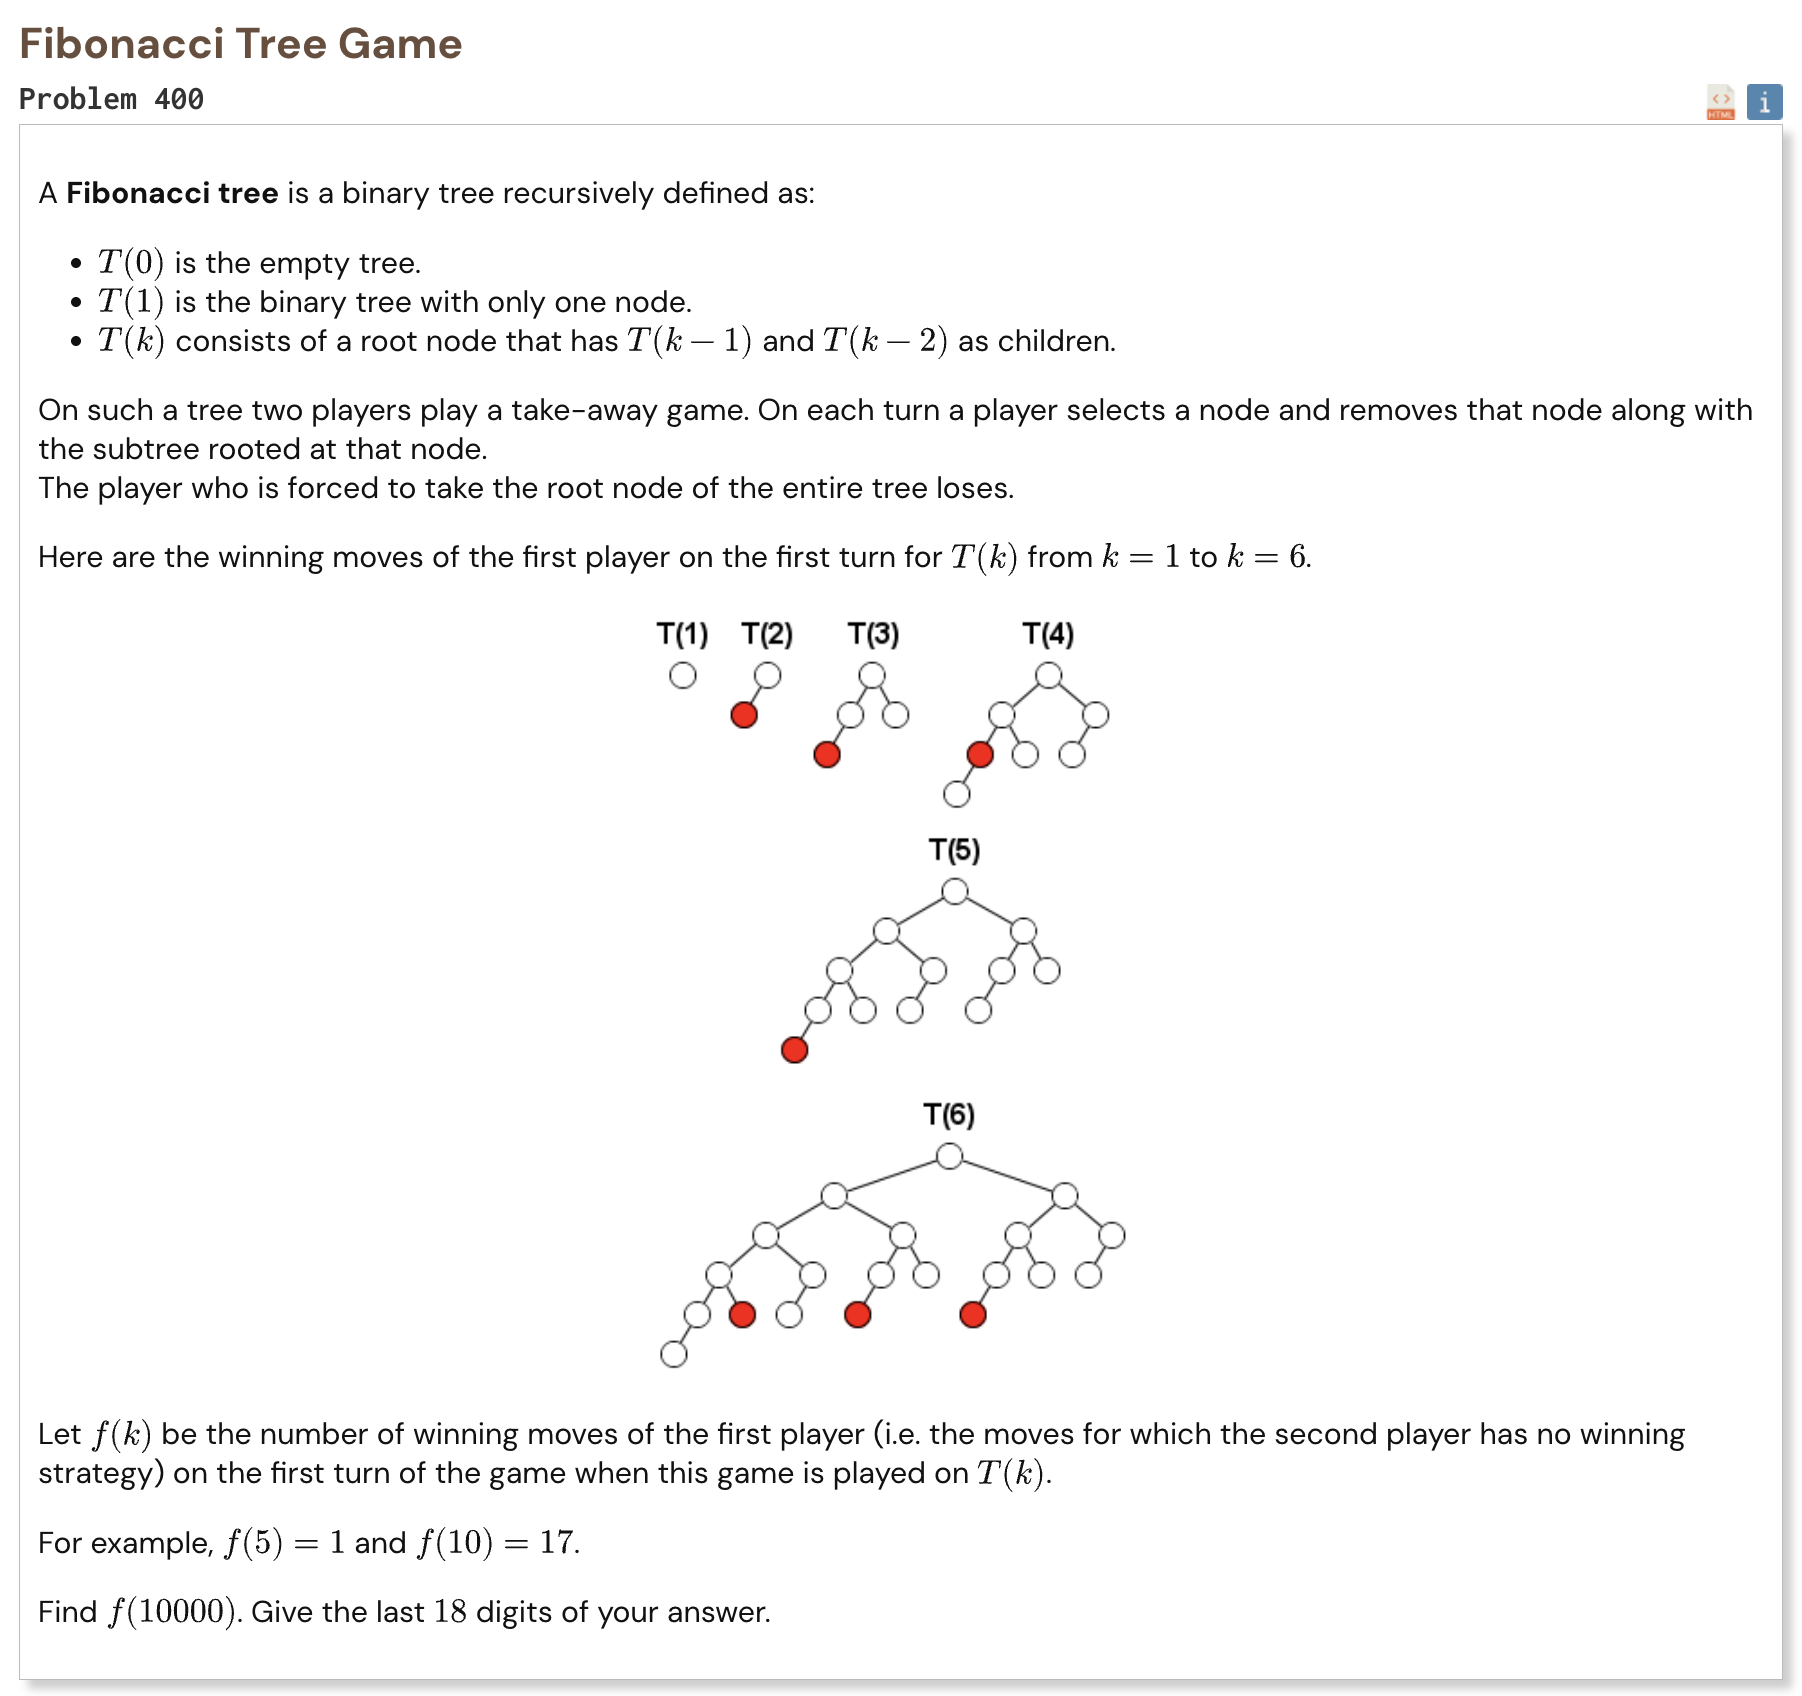

## Initial approach

-   use Sprague Grundy values to describe whether each remaining subtree is winning or losing
-   let h k be the Grundy value when the root of T k may also be removed
-   removing the root gives zero and the two child trees combine with xor
-   this gives the recurrence h k equals h k minus 1 xor h k minus 2 plus one
-   store how many moves in each tree produce every possible Grundy value
-   a first move is winning when the changed subtree matches the Grundy value of the other subtree
-   update the move counts from the two smaller Fibonacci trees
-   keep every count modulo ten to the power eighteen

In [1]:
%%time

MOD = 10 ** 18
N = 10000

grundy = [0] * (N + 1)
grundy[1] = 1
grundy[2] = 2

for k in range(3, N + 1):
    grundy[k] = (grundy[k - 1] ^ grundy[k - 2]) + 1

state_count = 1 << max(grundy).bit_length()

previous_two = [0] * state_count
previous_one = [0] * state_count
previous_one[0] = 1

result = 0

for k in range(2, N + 1):
    result = (
        previous_one[grundy[k - 2]]
        + previous_two[grundy[k - 1]]
    ) % MOD

    current = [0] * state_count
    current[0] = 1

    left_grundy = grundy[k - 2]
    right_grundy = grundy[k - 1]

    for value in range(1, state_count):
        current[value] = (
            previous_one[(value - 1) ^ left_grundy]
            + previous_two[(value - 1) ^ right_grundy]
        ) % MOD

    previous_two, previous_one = previous_one, current

print("Result:", f"{result:018d}")

Result: 438505383468410633
CPU times: user 19.8 s, sys: 80.2 ms, total: 19.9 s
Wall time: 19.9 s
